In [2]:
import pandas as pd

In [ ]:
df=pd.read_csv("dataset/babies.csv")
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   float64
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   float64
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 77.4 KB


In [5]:
df.describe()

,case,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,618.500000,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,356.946775,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,1236.000000,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


In [6]:
df.isnull().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
import matplotlib.pyplot as plt

In [10]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='object')

In [11]:
df.drop(columns=['case'],inplace=True)

In [12]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='object')

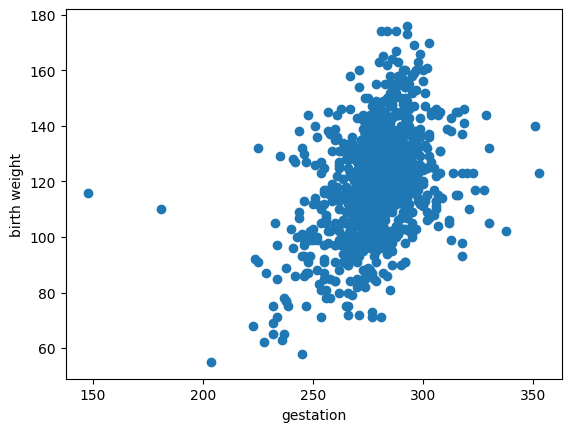

In [13]:
plt.scatter(df['gestation'],df['bwt'])
plt.xlabel('gestation')
plt.ylabel('birth weight')
plt.show()

In [14]:
df['smoke'].unique()

array([0., 1.])

In [15]:
df['smoke'].value_counts()

smoke
0.0    715
1.0    459
Name: count, dtype: int64

In [16]:
df['smoke'].value_counts(normalize=True)*100

smoke
0.0    60.902896
1.0    39.097104
Name: proportion, dtype: float64

In [17]:
df.corr()

,bwt,gestation,parity,age,height,weight,smoke
bwt,1.000000,0.407543,-0.043908,0.026983,0.203704,0.155923,-0.246800
gestation,0.407543,1.000000,0.080916,-0.053425,0.070470,0.023655,-0.060267
parity,-0.043908,0.080916,1.000000,-0.351041,0.043543,-0.096362,-0.009599
age,0.026983,-0.053425,-0.351041,1.000000,-0.006453,0.147322,-0.067772
height,0.203704,0.070470,0.043543,-0.006453,1.000000,0.435287,0.017507
weight,0.155923,0.023655,-0.096362,0.147322,0.435287,1.000000,-0.060281
smoke,-0.246800,-0.060267,-0.009599,-0.067772,0.017507,-0.060281,1.000000


In [18]:
y=df['bwt']
x=df.iloc[:,1:]
x.head()

,gestation,parity,age,height,weight,smoke
0,284.0,0,27.0,62.0,100.0,0.0
1,282.0,0,33.0,64.0,135.0,0.0
2,279.0,0,28.0,64.0,115.0,1.0
4,282.0,0,23.0,67.0,125.0,1.0
5,286.0,0,25.0,62.0,93.0,0.0


In [19]:
from sklearn.model_selection import train_test_split as tts

In [20]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.20)

In [21]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge 

In [22]:
lr=LinearRegression()
lesso=Lasso()
ridge=Ridge()

In [23]:
lr.fit(x_train,y_train)
lesso.fit(x_train,y_train)
ridge.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [24]:
lr_pred=lr.predict(x_test)
lasso_pred=lesso.predict(x_test)
ridge_pred=ridge.predict(x_test)

In [25]:
from sklearn.metrics import r2_score,mean_squared_error

In [26]:
lr_score=r2_score(y_test,lr_pred)
lasso_score=r2_score(y_test,lasso_pred)
ridge_score=r2_score(y_test,ridge_pred)

In [27]:
lr_mse=mean_squared_error(y_test,lr_pred)
lasso_mse=mean_squared_error(y_test,lasso_pred)
ridge_mse=mean_squared_error(y_test,ridge_pred)

In [28]:
print("\n performance of linear regression model")
print("r2score=",lr_score)
print("msescore=",lr_mse)

print("\n performance of lesso regression model")
print("r2score=",lasso_score)
print("msescore=",lasso_mse)

print("\n performance of ridge regression model")
print("r2score=",ridge_score)
print("msescore=",ridge_mse)


 performance of linear regression model
r2score= 0.18668177864964997
msescore= 243.91423031078233

 performance of lesso regression model
r2score= 0.166287344601469
msescore= 250.03052348226316

 performance of ridge regression model
r2score= 0.18663699268906275
msescore= 243.92766162563376


In [29]:
import pickle

In [30]:
with open("model/model1.pkl","wb") as f:
    pickle.dump(lr,f)

In [31]:
with open("model/model1.pkl","rb") as obj:
    mymodel=pickle.load(obj)

In [32]:
x_train.head()

,gestation,parity,age,height,weight,smoke
266,294.0,0,40.0,64.0,125.0,0.0
936,252.0,0,21.0,64.0,120.0,0.0
456,262.0,1,32.0,64.0,125.0,0.0
702,271.0,1,26.0,66.0,135.0,0.0
875,293.0,1,19.0,65.0,150.0,0.0


In [33]:
mymodel.predict(x_train)

array([129.83951583, 110.60520026, 111.98229208, 119.32488672,
       128.97512774, 104.28427513, 127.96856354, 124.3107651 ,
       117.93679413, 102.45159435, 110.39548475, 130.39873075,
       121.35566475, 107.3837046 , 121.09302052, 123.90543864,
       134.78614184, 117.35512629, 111.45569577, 103.43507119,
       114.38000001, 115.54144006, 120.21386503, 122.51256205,
       115.89095749, 123.87704809, 114.41625692, 120.65167276,
       116.95342503, 110.28286733, 114.29462757, 115.59948129,
       112.40273566,  98.59526182, 140.96523563, 100.77556723,
       129.18208426,  98.3324077 , 122.69641377, 119.10206623,
       117.75740631, 115.68870134, 112.39966593, 126.07658821,
       124.7211099 , 129.51162032, 124.02020963, 131.80277494,
       111.99180111, 120.5191505 , 127.61424644, 115.34606029,
       109.26942909, 116.36811247, 105.97319336, 122.82889827,
       126.0870471 , 118.655012  ,  96.02476133, 135.07498071,
       125.34111358, 110.53887361, 115.01833372, 109.26